In [14]:
import random
import pandas as pd
import numpy as np

RANDOM_STATE = 123
random.seed(RANDOM_STATE)

N = 50
df_name = "AAPL_15min"

df = pd.read_csv(f'datasets/{df_name}_marked.csv')

TRAIN_SIZE = int(0.8 * df.shape[0])
df_train, df_test = df[:TRAIN_SIZE], df[TRAIN_SIZE:]

In [15]:
def build_vectors_by_price(df, N, take_all=False):
    vectors = []
    n = df.shape[0]
    for i in range(N, n):
        if df.iloc[i]['is_min'] or take_all:
            cur_vec = []
            for j in range(i - 1, i - N, -1):
                cur_vec.append((df.iloc[j]['close'] - df.iloc[i]['close']) / df.iloc[i]['close'])
            vectors.append(cur_vec)
    return np.array(vectors)

X_train = build_vectors_by_price(df_train, N)
X_train.shape

(276, 49)

**Строим векторы отношений цен для трейна**

In [16]:
X_train[0]

array([0.0539439 , 0.06458931, 0.06746584, 0.06880839, 0.06784944,
       0.0723088 , 0.07137377, 0.06784944, 0.07499401, 0.07806281,
       0.07715176, 0.07801491, 0.07520978, 0.07879549, 0.07705586,
       0.06883241, 0.07027092, 0.06765764, 0.06847279, 0.06653081,
       0.06641088, 0.0710621 , 0.06763366, 0.05890678, 0.07039079,
       0.07206905, 0.04665548, 0.04473747, 0.04557655, 0.04382642,
       0.04289139, 0.04210022, 0.04430587, 0.04483333, 0.04833373,
       0.04219616, 0.04603208, 0.0465356 , 0.04886123, 0.04900024,
       0.05164234, 0.05449149, 0.0539439 , 0.05169024, 0.05749216,
       0.05691681, 0.05962599, 0.06017746, 0.06104052])

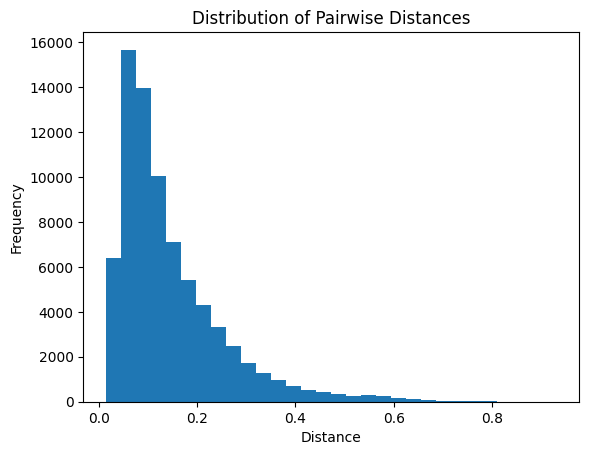

In [17]:
from matplotlib import pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

distances = euclidean_distances(X_train)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=30)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

In [18]:
from sklearn.cluster import DBSCAN, KMeans

EPS = 0.1
clustering_dbscan = DBSCAN(eps=EPS, min_samples=5).fit(X_train)
clustering_dbscan.labels_

array([-1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0, -1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1,  0,  0,  0,  0,  0,
       -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0

In [19]:
noise = np.where(clustering_dbscan.labels_ == -1)[0]
noise

array([  0, 141, 142, 158, 159, 160, 161, 162, 163, 164, 170, 230])

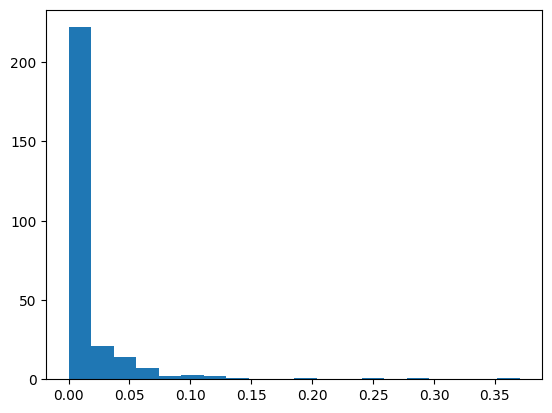

In [20]:
squared = np.diagonal(X_train @ X_train.T)
plt.hist(squared, bins=20)
plt.show()

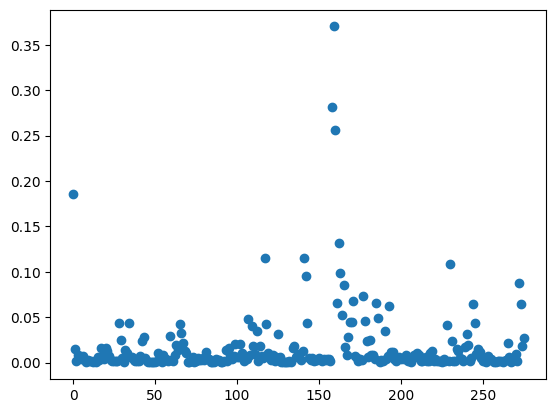

In [21]:
plt.scatter([i for i in range(squared.shape[0])], squared)
plt.show()

In [22]:
squared[noise]

array([0.18609538, 0.11523922, 0.09557414, 0.28134211, 0.37023632,
       0.25673877, 0.0656984 , 0.13209996, 0.09920786, 0.05288967,
       0.04472939, 0.10875973])

In [23]:
clustering_kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE).fit(X_train)
clustering_kmeans.labels_

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0], dtype=int32)

**Проверяем DBSCAN accuracy на тесте**

In [24]:
X_test = build_vectors_by_price(df_test, N, take_all=True)

In [25]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score


def predict_dbscan(X_train, v, eps):
    # Расстояния от v до всех core points
    distances = euclidean_distances([v], X_train[clustering_dbscan.core_sample_indices_])[0]
    
    min_dist_idx = np.argmin(distances)
    min_dist = distances[min_dist_idx]
    
    # Если ближайший core point в пределах eps — присваиваем его кластер
    if min_dist <= eps:
        return clustering_dbscan.labels_[clustering_dbscan.core_sample_indices_[min_dist_idx]]
    else:
        return -1  # шум

y_true = df_test['is_min'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_dbscan(X_train, X_test[i - N], EPS)
    if (prediction == -1):
        print(i)
    y_pred.append(prediction != -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
print(f"DBSCAN - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}")

1961
1962
1963
1964
1965
1966
1967
1968
1969
1970
1971
1972
1973
1974
1975
1976
1977
1978
1979
1980
1981
1982
1983
DBSCAN - Accuracy: 0.0421, Recall: 1.0000, Precision: 0.0306, F1 Score: 0.0594


**Проверяем Kmeans accuracy на тесте**

In [26]:
def predict_kmeans(v, threshold=None):
    label = clustering_kmeans.predict([v])[0]
    
    if threshold is not None:
        dist = euclidean_distances([v], [clustering_kmeans.cluster_centers_[label]])[0][0]
        if dist > threshold:
            return -1  # считаем выбросом
    
    return label

y_true = df_test['is_min'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_kmeans(X_test[i - N], threshold=EPS)
    if (prediction == -1):
        print(i)
    y_pred.append(prediction != -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
print(f"Kmeans - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}")

472
473
474
476
516
517
529
532
535
543
568
574
582
594
595
596
597
598
686
688
689
690
691
692
693
694
695
696
697
698
699
777
778
1249
1308
1309
1347
1348
1350
1354
1355
1357
1358
1530
1551
1552
1553
1584
1585
1586
1612
1613
1614
1615
1616
1617
1618
1619
1620
1621
1622
1623
1624
1625
1626
1627
1628
1629
1630
1631
1632
1633
1634
1635
1636
1637
1638
1639
1640
1641
1642
1643
1644
1645
1646
1647
1648
1649
1650
1651
1652
1653
1654
1655
1667
1668
1669
1670
1671
1672
1686
1687
1688
1689
1690
1694
1696
1697
1714
1741
1742
1743
1744
1745
1746
1747
1748
1749
1750
1751
1752
1753
1754
1755
1756
1757
1758
1759
1760
1761
1762
1763
1764
1765
1766
1767
1768
1769
1770
1771
1772
1773
1774
1775
1776
1777
1778
1779
1780
1781
1782
1783
1784
1785
1792
1793
1794
1795
1796
1797
1798
1799
1800
1801
1802
1803
1815
1845
1870
1871
1872
1895
1896
1897
1898
1899
1927
1928
1933
1934
1948
1949
1950
1951
1953
1954
1955
1956
1957
1958
1959
1960
1961
1962
1963
1964
1965
1966
1967
1968
1969
1970
1971
1972
1973
1974
197